In [1]:
!pip install -q torchmetrics iterative-stratification optuna shap
!pip install -q huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 42.0 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

from datasets import load_dataset

pd.set_option("display.max_columns", 136)

root = "ADS599-Capstone/modeling_data"

df_patient = load_dataset(path=root, name='full_patient_state', split='full_patient_state').to_pandas()
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

README.md: 0.00B [00:00, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.67M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.72M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.63M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.52M [00:00<?, ?B/s]

...

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.69M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.62M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.70M [00:00<?, ?B/s]

full_patient_state/full_patient_state-00(…):   0%|          | 0.00/7.57M [00:00<?, ?B/s]

Generating full_patient_state split:   0%|          | 0/6551723 [00:00<?, ? examples/s]

In [4]:
torch.manual_seed(10)
np.random.seed(10)
torch.cuda.manual_seed(10)
torch.cuda.manual_seed_all(10)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [5]:
# Keep only unique state rows per stay
drop_cols = df_patient.columns[4:].tolist()
drop_cols.remove("time_since_last_hrs")
drop_cols.append("ed_stay_id")
df_model = df_patient.drop_duplicates(subset=drop_cols).copy()

print(f"Original rows: {len(df_patient):,}")
print(f"Filtered rows: {len(df_model):,}")
print(f"Reduction:     {1 - len(df_model)/len(df_patient):.1%}")
print("Terminal event distribution:")
print(df_model.drop_duplicates("ed_stay_id")["terminal_event"].value_counts())


Original rows: 6,551,723
Filtered rows: 1,122,668
Reduction:     82.9%
Terminal event distribution:
terminal_event
DISCHARGE_ED      38130
DISCHARGE_WARD    27834
ICU               18247
Name: count, dtype: int64


# Preprocess and One-Hot-Encode Categorical Columns

In [6]:
# Map Gender
gender_map = {"F": 1, "M": 0}
df_model["gender"] = df_model["gender"].map(gender_map)

# Change acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Mask height and weight
df_model["height_missing"] = df_model["height"].isna().astype(int)
df_model["weight_missing"] = df_model["weight"].isna().astype(int)
df_model[["height", "weight"]] = df_model[["height", "weight"]].fillna(0)

# Create pain_missing column and convert the Other category to 0
df_model["pain_missing"] = (df_model["current_pain"] == "Other").astype(int)
df_model["current_pain"] = pd.to_numeric(df_model["current_pain"], errors="coerce").fillna(0)

# Mask admission type then one hot encode admission and arrival
df_model["admission_missing"] = df_model["admission_type"].isna().astype(int)
at_dummies = pd.get_dummies(df_model["admission_type"], prefix="admission_type", dummy_na=False, dtype=int)
arrival_dummies = pd.get_dummies(df_model["arrival_transport"], prefix="arrival_transport", dtype=int)
df_model_updated = pd.concat([df_model, at_dummies, arrival_dummies], axis=1).drop(columns=["admission_type", "arrival_transport"])


# Isolate Columns

In [7]:
# Columns out of order so this pieces all the state cols together
vitals = [c for c in df_model_updated.loc[:, "current_temperature":"dbp_rate"].columns if not c.endswith("_rate") and not c.endswith("_delta")]
med_cols = [c for c in df_model_updated.columns if c.startswith("recon")]
admission_cols = at_dummies.columns.to_list() + ["admission_missing"]
arrival_cols = arrival_dummies.columns.to_list()

# Definitive list of patient state cols (124 features)
state_cols = df_model_updated.columns[4:71].to_list() + ["gender", "anchor_age", "acuity", "height", "height_missing", "weight_missing", "pain_missing"] + med_cols + vitals + admission_cols + arrival_cols

print(f"State cols: {len(state_cols)}")


State cols: 124


# Sequence Modeling

## Split Data

In [9]:
pad_length = df_model_updated.groupby('ed_stay_id').size().max()

# Encode terminal event: discharge=0, ICU=1
terminal_event_mapping = {"DISCHARGE_WARD": 0, "DISCHARGE_ED": 0, "ICU": 1}
df_model_updated["terminal_code"] = df_model_updated["terminal_event"].map(terminal_event_mapping)

valid_stays = df_model_updated.groupby("ed_stay_id").size()
valid_stays = valid_stays[valid_stays < pad_length].index
df_modeling = df_model_updated[df_model_updated["ed_stay_id"].isin(valid_stays)]
print(f"Stays after length filter: {df_modeling['ed_stay_id'].nunique():,}")


Stays after length filter: 84,210


This drop stays from the group that last less than 400 time steps.  Removes less than 1000 records from the group of 84k

In [10]:
def pad_stays(df, max_len=pad_length):
    grouped = df.groupby("ed_stay_id")
    states, labels, lengths = [], [], []

    for stay_id, group in grouped:
        s = group[state_cols].values.astype(np.float32)
        pad_len = max_len - len(s)
        s = np.pad(s, ((0, pad_len), (0, 0)))  # pad rows, not features
        label = int(group["terminal_code"].iloc[0])  # single label per stay
        states.append(s)
        labels.append(label)
        lengths.append(len(group))

    return np.stack(states), np.array(labels, dtype=np.int64), np.array(lengths)


In [11]:
stay_labels = (
    df_modeling.drop_duplicates("ed_stay_id")[["ed_stay_id", "terminal_code"]]
    .reset_index(drop=True)
)

train_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=10)
train_idx, test_idx = next(train_split.split(stay_labels, stay_labels["terminal_code"]))

train_stays = set(stay_labels.iloc[train_idx]["ed_stay_id"])
test_stays  = set(stay_labels.iloc[test_idx]["ed_stay_id"])

df_train = df_modeling[df_modeling["ed_stay_id"].isin(train_stays)].copy()
df_test  = df_modeling[df_modeling["ed_stay_id"].isin(test_stays)].copy()

print(f"Train stays: {df_train['ed_stay_id'].nunique():,}")
print(df_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nTest stays:  {df_test['ed_stay_id'].nunique():,}")
print(df_test.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nOverlap: {train_stays.intersection(test_stays)}")


Train stays: 67,368
terminal_event
DISCHARGE_ED      30513
DISCHARGE_WARD    22258
ICU               14597
Name: count, dtype: int64

Test stays:  16,842
terminal_event
DISCHARGE_ED      7617
DISCHARGE_WARD    5576
ICU               3649
Name: count, dtype: int64

Overlap: set()


## Scale and Pad Data

In [12]:
scale = StandardScaler()
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']

df_train[scaling_cols] = scale.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scale.transform(df_test[scaling_cols])

In [13]:
missing = [c for c in state_cols if c not in df_train.columns]
extra = [c for c in df_train.columns if c not in state_cols + ["ed_stay_id", "subject_id", "hadm_id", "time", "terminal_event", "terminal_code", "ed_boarding"]]
print(f"In state_cols but not in df_train: {missing}")
print(f"In df_train but not accounted for: {extra}")


In state_cols but not in df_train: []
In df_train but not accounted for: ['temperature_delta', 'temperature_rate', 'heartrate_delta', 'heartrate_rate', 'resprate_delta', 'resprate_rate', 'o2sat_delta', 'o2sat_rate', 'sbp_delta', 'sbp_rate', 'dbp_delta', 'dbp_rate', 'observe', 'dispense_meds', 'ward_transfer', 'discharge', 'transfer_icu', 'ecg_ordered', 'rad_ordered', 'vitals_checked', 'labs_ordered', 'micro_ordered']


In [14]:
df_train.drop(columns=extra, inplace=True)
df_test.drop(columns=extra, inplace=True)

In [15]:
# Configurations
batch_size = 16
input_size = 124
hidden_size = 256
num_layers = 2
dropout = 0.2
num_classes = 2   # discharge=0, ICU=1
epochs = 5


In [16]:
# Prep train
s_train, y_train, train_len = pad_stays(df_train)
s_train   = torch.tensor(s_train)
y_train   = torch.tensor(y_train)   # (N,) int64
train_len = torch.tensor(train_len)

# Prep test
s_test, y_test, test_len = pad_stays(df_test)
s_test   = torch.tensor(s_test)
y_test   = torch.tensor(y_test)
test_len = torch.tensor(test_len)

train_loader = DataLoader(
    TensorDataset(s_train, y_train, train_len),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(10),
)
test_loader = DataLoader(
    TensorDataset(s_test, y_test, test_len),
    batch_size=batch_size, shuffle=False,
)

print(f"State dim:   {s_train.shape[2]}")
print(f"Train stays: {s_train.shape[0]:,}")
print(f"Test stays:  {s_test.shape[0]:,}")
print(f"Train class: discharge={(y_train==0).sum():,}  icu={(y_train==1).sum():,}")
print(f"Test  class: discharge={(y_test==0).sum():,}  icu={(y_test==1).sum():,}")


State dim:   124
Train stays: 67,368
Test stays:  16,842
Train class: discharge=52,771  icu=14,597
Test  class: discharge=13,193  icu=3,649


# Modeling Set Up

In [26]:
class SequenceModeling(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        output, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(output, batch_first=True)  # (B, T_max, hidden)
        return self.fc(output)  # (B, T_max, 2) logits at every timestep

seq_model = SequenceModeling().to(device)
print(seq_model)


SequenceModeling(
  (lstm): LSTM(124, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [27]:
# Class weight to handle ICU minority class
stay_labels_train = df_train.drop_duplicates("ed_stay_id")["terminal_code"].values
labels_all   = torch.tensor(stay_labels_train)
n_discharge  = (labels_all == 0).sum().float()
n_icu        = (labels_all == 1).sum().float()
class_weight = torch.tensor([1.0, (n_discharge / n_icu).item()]).to(device)
print(f"Class weights: discharge={class_weight[0]:.2f}  icu={class_weight[1]:.2f}")

learning_rate = 1e-4
loss_fn   = nn.CrossEntropyLoss(weight=class_weight)
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=learning_rate)


Class weights: discharge=1.00  icu=3.62


## Training Loop

In [19]:
from torchmetrics.classification import MulticlassF1Score
f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
f1_per_class = MulticlassF1Score(num_classes=num_classes, average="none")


In [25]:
def training_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y, lengths) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred  = model(X, lengths)          # (B, T_max, 2)
        T_max = pred.shape[1]
        y_seq = y.unsqueeze(1).expand(-1, T_max)                                     # (B, T_max)
        mask  = torch.arange(T_max, device=device).unsqueeze(0) < lengths.to(device).unsqueeze(1)
        loss  = loss_fn(pred[mask], y_seq[mask])                                     # (N_real, 2) vs (N_real,)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 200 == 0:
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7.4f} [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)


In [24]:
def evaluation_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0
    preds, true_y, all_seq_probs, all_lengths = [], [], [], []

    model.eval()
    with torch.no_grad():
        for X, y, lengths in dataloader:
            X, y = X.to(device), y.to(device)
            pred  = model(X, lengths)              # (B, T_max, 2)
            T_max = pred.shape[1]
            y_seq = y.unsqueeze(1).expand(-1, T_max)
            mask  = torch.arange(T_max, device=device).unsqueeze(0) < lengths.to(device).unsqueeze(1)
            test_loss += loss_fn(pred[mask], y_seq[mask]).item()

            # Pad each batch's seq_probs to pad_length so all batches can be concatenated
            seq_probs = torch.softmax(pred, dim=-1).cpu()  # (B, T_max, 2)
            pad_needed = pad_length - T_max
            if pad_needed > 0:
                seq_probs = torch.nn.functional.pad(seq_probs, (0, 0, 0, pad_needed))
            all_seq_probs.append(seq_probs)
            all_lengths.append(lengths.cpu())

            # Last real timestep per stay for F1 / downstream metrics
            last_idx  = (lengths - 1).to(device)
            last_pred = pred[torch.arange(len(lengths), device=device), last_idx]  # (B, 2)
            preds.append(torch.softmax(last_pred, dim=-1).cpu())
            true_y.append(y.cpu())

    final_preds   = torch.cat(preds, dim=0)          # (N, 2)
    true_labels   = torch.cat(true_y, dim=0)         # (N,)
    seq_probs_all = torch.cat(all_seq_probs, dim=0)  # (N, pad_length, 2)
    lengths_all   = torch.cat(all_lengths, dim=0)    # (N,)

    test_loss /= num_batches
    f1_macro = f1(final_preds, true_labels).item()
    f1_per   = f1_per_class(final_preds, true_labels)
    print(f"\nAvg Loss: {test_loss:.4f}  F1_Macro: {f1_macro:.4f}")
    for cls, score in zip(["discharge", "icu"], f1_per.tolist()):
        print(f"  {cls}: {score:.4f}")

    return final_preds, true_labels, test_loss, seq_probs_all, lengths_all


In [28]:
import os, tempfile
from huggingface_hub import HfApi

train_losses = []
eval_losses  = []

# Early stopping config
patience          = 3
best_eval_loss    = float("inf")
epochs_no_improve = 0
best_model_state  = None
best_epoch        = 0
hf_repo_id        = "ADS599-Capstone/disposition_lstm_model"
hf_filename       = "lstm_step_model_best.pt"

hf_api = HfApi()
hf_api.create_repo(hf_repo_id, exist_ok=True, private=True)

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}------------------------------")
    t_loss = training_loop(train_loader, seq_model, loss_fn, optimizer)
    train_losses.append(t_loss)
    final_preds, true_labels, e_loss, seq_probs_all, lengths_all = evaluation_loop(test_loader, seq_model, loss_fn)
    eval_losses.append(e_loss)

    if e_loss < best_eval_loss:
        best_eval_loss    = e_loss
        best_epoch        = epoch + 1
        best_model_state  = {k: v.clone() for k, v in seq_model.state_dict().items()}
        epochs_no_improve = 0
        # Save to HuggingFace Hub
        with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as tmp:
            torch.save(best_model_state, tmp.name)
            tmp_path = tmp.name
        hf_api.upload_file(
            path_or_fileobj=tmp_path,
            path_in_repo=hf_filename,
            repo_id=hf_repo_id,
        )
        os.unlink(tmp_path)
        print(f"  ** New best eval loss: {best_eval_loss:.4f} (saved to {hf_repo_id}/{hf_filename})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}. Best was epoch {best_epoch}.")
            break

# Restore best model
if best_model_state is not None:
    seq_model.load_state_dict(best_model_state)
    print(f"\nRestored model from epoch {best_epoch} (eval loss: {best_eval_loss:.4f})")
    final_preds, true_labels, _, seq_probs_all, lengths_all = evaluation_loop(test_loader, seq_model, loss_fn)



Epoch 1------------------------------
loss:  0.6782 [   16/67368]
loss:  0.5501 [ 3216/67368]
loss:  0.5084 [ 6416/67368]
loss:  0.5367 [ 9616/67368]
loss:  0.5035 [12816/67368]
loss:  0.4581 [16016/67368]
loss:  0.3050 [19216/67368]
loss:  0.3368 [22416/67368]
loss:  0.5933 [25616/67368]
loss:  0.4152 [28816/67368]
loss:  0.4859 [32016/67368]
loss:  0.4399 [35216/67368]
loss:  0.3855 [38416/67368]
loss:  0.5154 [41616/67368]
loss:  0.5569 [44816/67368]
loss:  0.4112 [48016/67368]
loss:  0.4244 [51216/67368]
loss:  0.4488 [54416/67368]
loss:  0.6841 [57616/67368]
loss:  0.2851 [60816/67368]
loss:  0.5671 [64016/67368]
loss:  0.3213 [67216/67368]

Avg Loss: 0.4593  F1_Macro: 0.8258
  discharge: 0.9085
  icu: 0.7431


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmpdc3ihzh6.pt         :  15%|#5        |  558kB / 3.68MB            

  ** New best eval loss: 0.4593 (saved to ADS599-Capstone/disposition_lstm_model/lstm_step_model_best.pt)

Epoch 2------------------------------
loss:  0.5492 [   16/67368]
loss:  0.4428 [ 3216/67368]
loss:  0.4113 [ 6416/67368]
loss:  0.6090 [ 9616/67368]
loss:  0.3567 [12816/67368]
loss:  0.6374 [16016/67368]
loss:  0.3294 [19216/67368]
loss:  0.4431 [22416/67368]
loss:  0.3742 [25616/67368]
loss:  0.3436 [28816/67368]
loss:  0.4299 [32016/67368]
loss:  0.5613 [35216/67368]
loss:  0.3751 [38416/67368]
loss:  0.4993 [41616/67368]
loss:  0.2693 [44816/67368]
loss:  0.4042 [48016/67368]
loss:  0.7797 [51216/67368]
loss:  0.3912 [54416/67368]
loss:  0.2973 [57616/67368]
loss:  0.5659 [60816/67368]
loss:  0.4389 [64016/67368]
loss:  0.4164 [67216/67368]

Avg Loss: 0.4449  F1_Macro: 0.8436
  discharge: 0.9200
  icu: 0.7673


...

  ** New best eval loss: 0.4374 (saved to ADS599-Capstone/disposition_lstm_model/lstm_step_model_best.pt)

Epoch 5------------------------------
loss:  0.1622 [   16/67368]
loss:  0.2433 [ 3216/67368]
loss:  0.5393 [ 6416/67368]
loss:  0.3491 [ 9616/67368]
loss:  0.3536 [12816/67368]
loss:  0.2080 [16016/67368]
loss:  0.3534 [19216/67368]
loss:  0.3615 [22416/67368]
loss:  0.5288 [25616/67368]
loss:  0.2651 [28816/67368]
loss:  0.5202 [32016/67368]
loss:  0.5884 [35216/67368]
loss:  0.4967 [38416/67368]
loss:  0.3907 [41616/67368]
loss:  0.2237 [44816/67368]
loss:  0.5259 [48016/67368]
loss:  0.3203 [51216/67368]
loss:  0.4048 [54416/67368]
loss:  0.4233 [57616/67368]
loss:  0.4409 [60816/67368]
loss:  0.2129 [64016/67368]
loss:  0.2922 [67216/67368]

Avg Loss: 0.4343  F1_Macro: 0.8526
  discharge: 0.9252
  icu: 0.7801


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp1hkg2n4l.pt         :  91%|#########1| 3.36MB / 3.68MB            

  ** New best eval loss: 0.4343 (saved to ADS599-Capstone/disposition_lstm_model/lstm_step_model_best.pt)

Restored model from epoch 5 (eval loss: 0.4343)

Avg Loss: 0.4343  F1_Macro: 0.8526
  discharge: 0.9252
  icu: 0.7801


In [57]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_model(hs, nl, dr):
    class _Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hs,
                                num_layers=nl, batch_first=True,
                                dropout=dr if nl > 1 else 0.0)
            self.fc = nn.Linear(hs, num_classes)
        def forward(self, x, lengths):
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
            return self.fc(h_n[-1])
    return _Model().to(device)

def objective(trial):
    hs = trial.suggest_categorical('hidden_size', [128, 256, 512])
    nl = trial.suggest_int('num_layers', 1, 3)
    dr = trial.suggest_float('dropout', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [16, 32, 64])

    model = build_model(hs, nl, dr)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr)

    loader_tr = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=bs, shuffle=True,
                       generator=torch.Generator().manual_seed(42))
    loader_te = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=bs, shuffle=False)

    best_loss = float('inf')
    patience_t, no_improve = 3, 0

    for epoch in range(10):
        training_loop(loader_tr, model, loss_fn, opt)
        _, _, e_loss = evaluation_loop(loader_te, model, loss_fn)

        trial.report(e_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if e_loss < best_loss:
            best_loss = e_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_t:
                break

    return best_loss


In [58]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('Best trial:')
print(f'  Eval loss: {study.best_value:.4f}')
print(f'  Params:    {study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]

loss:  0.6954 [   32/67368]
loss:  0.4753 [ 3232/67368]
loss:  0.4204 [ 6432/67368]
loss:  0.4781 [ 9632/67368]
loss:  0.6946 [12832/67368]
loss:  0.4710 [16032/67368]
loss:  0.3771 [19232/67368]
loss:  0.3113 [22432/67368]
loss:  0.2015 [25632/67368]
loss:  0.1127 [28832/67368]
loss:  0.3444 [32032/67368]

Avg Loss: 0.2677  F1_Macro: 0.8385
  discharge: 0.9167
  icu: 0.7603
loss:  0.3667 [   32/67368]
loss:  0.2766 [ 3232/67368]
loss:  0.2258 [ 6432/67368]
loss:  0.2358 [ 9632/67368]
loss:  0.2190 [12832/67368]
loss:  0.2638 [16032/67368]
loss:  0.2103 [19232/67368]
loss:  0.3361 [22432/67368]
loss:  0.5556 [25632/67368]
loss:  0.0844 [28832/67368]
loss:  0.1075 [32032/67368]

Avg Loss: 0.1973  F1_Macro: 0.9036
  discharge: 0.9568
  icu: 0.8504
loss:  0.2016 [   32/67368]
loss:  0.1281 [ 3232/67368]
loss:  0.2680 [ 6432/67368]
loss:  0.0933 [ 9632/67368]
loss:  0.0904 [12832/67368]
loss:  0.1270 [16032/67368]
loss:  0.1250 [19232/67368]
loss:  0.1842 [22432/67368]
loss:  0.1214 [25632

In [59]:
# Retrain with best hyperparameters from Optuna
bp      = study.best_params
best_hs = bp['hidden_size']
best_nl = bp['num_layers']
best_dr = bp['dropout']
best_lr = bp['lr']
best_bs = bp['batch_size']

print(f'Retraining with: hidden={best_hs}  layers={best_nl}  dropout={best_dr:.3f}  lr={best_lr:.2e}  batch={best_bs}')

seq_model    = build_model(best_hs, best_nl, best_dr)
optimizer    = torch.optim.AdamW(seq_model.parameters(), lr=best_lr)
train_loader = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=best_bs, shuffle=True)
test_loader  = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=best_bs, shuffle=False)

# Re-run the epoch loop cell (66801b6c) to train with early stopping


Retraining with: hidden=512  layers=2  dropout=0.269  lr=1.90e-04  batch=16


shap_values is an array of shape: (200, 99, 124, 2)


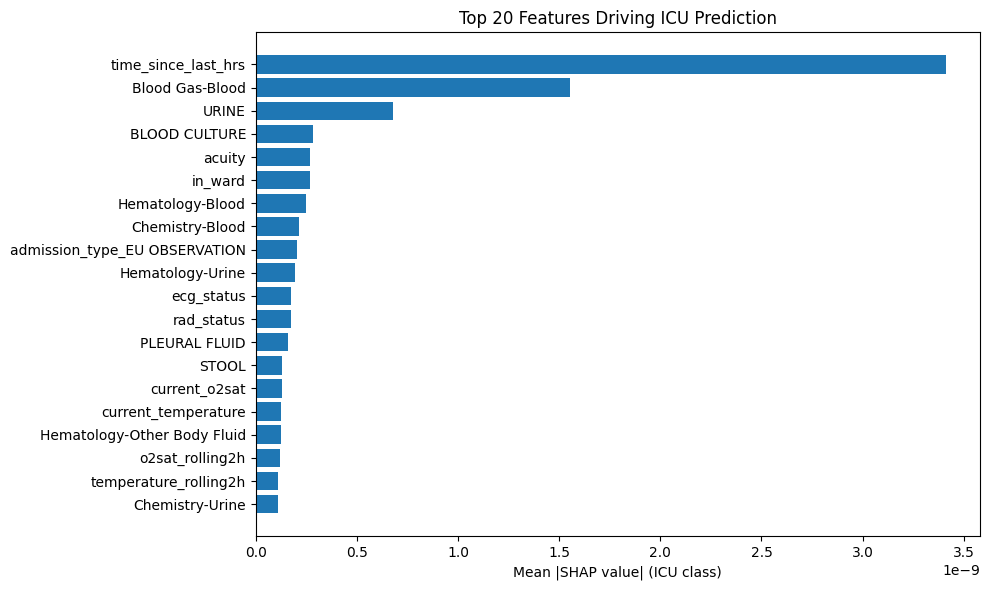

In [74]:
import shap

# GradientExplainer requires training mode for cuDNN RNN gradient computation
seq_model.train()

# Background: 200 random training samples
bg_idx  = torch.randperm(s_train.shape[0], generator=torch.Generator().manual_seed(10))[:200]
bg_data = s_train[bg_idx].to(device)

class ModelWrapper(nn.Module):
    def forward(self, x):
        lengths = torch.full((x.shape[0],), x.shape[1], dtype=torch.long)
        packed  = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = seq_model.lstm(packed)
        return seq_model.fc(h_n[-1])

wrapper = ModelWrapper().to(device)

n_explain = 200
exp_idx   = torch.randperm(s_test.shape[0], generator=torch.Generator().manual_seed(10))[:n_explain]
exp_data  = s_test[exp_idx].to(device)

explainer   = shap.GradientExplainer(wrapper, bg_data)
shap_values = explainer.shap_values(exp_data)

seq_model.eval()

# Inspect structure
if isinstance(shap_values, list):
    print(f'shap_values is a list of {len(shap_values)} arrays')
    for i, sv in enumerate(shap_values):
        print(f'  [{i}] shape: {np.array(sv).shape}')
    # ICU class = index 1 if 2 elements, else last axis
    shap_icu_raw = np.array(shap_values[1])
else:
    shap_values = np.array(shap_values)
    print(f'shap_values is an array of shape: {shap_values.shape}')
    # Newer shap: shape (n_explain, T, 124, 2) — take ICU class (axis -1, index 1)
    shap_icu_raw = shap_values[..., 1]

# Aggregate: mean |SHAP| across timesteps then samples -> (124,)
mean_shap = np.abs(shap_icu_raw).mean(axis=1).mean(axis=0)  # (124,)

# Plot top 20 features
top_idx   = np.argsort(mean_shap)[::-1][:20]
top_vals  = mean_shap[top_idx]
top_names = [state_cols[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names[::-1], top_vals[::-1])
ax.set_xlabel('Mean |SHAP value| (ICU class)')
ax.set_title('Top 20 Features Driving ICU Prediction')
plt.tight_layout()
plt.show()


/tmp/ipykernel_822/2212334461.py:12: RuntimeWarning: Mean of empty slice
  mean_discharge = np.nanmean(picu_matrix[discharge_mask], axis=0)
/tmp/ipykernel_822/2212334461.py:13: RuntimeWarning: Mean of empty slice
  mean_icu       = np.nanmean(picu_matrix[icu_mask],       axis=0)


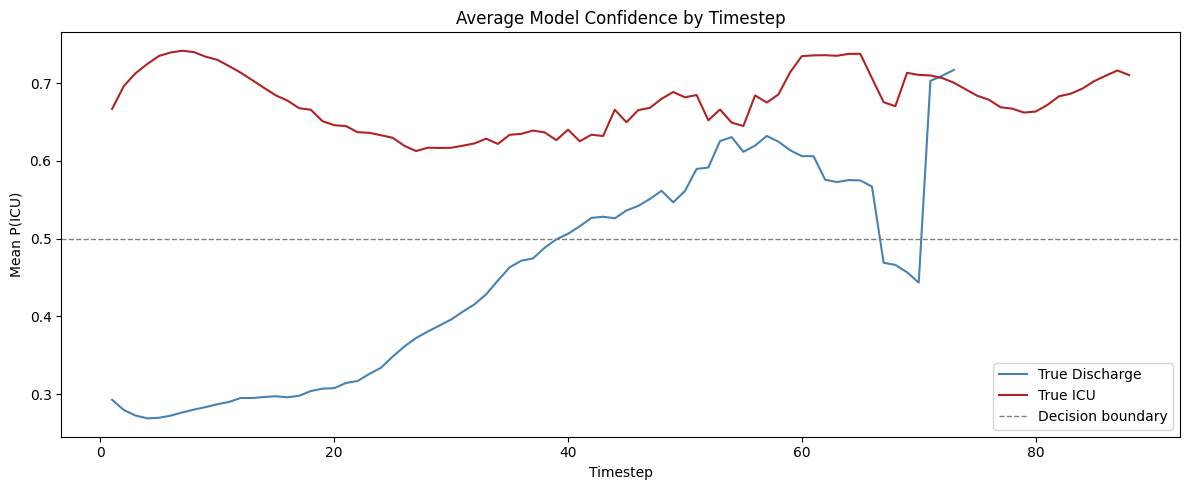

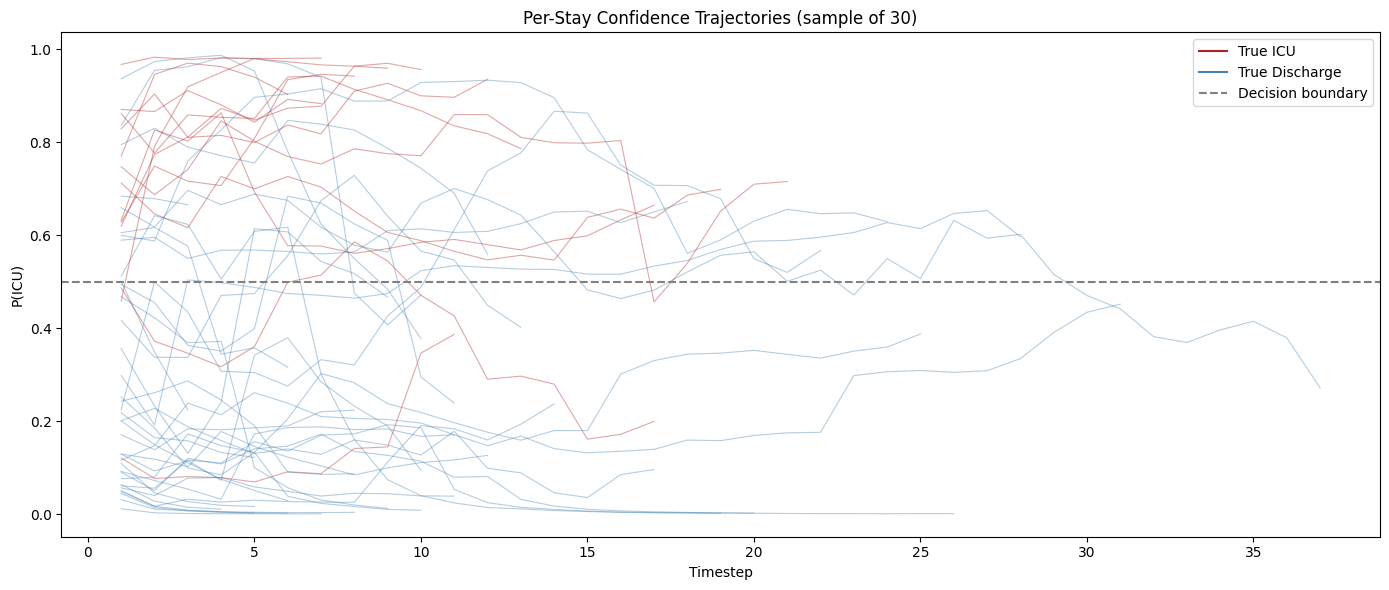

In [34]:
# Per-timestep confidence plots
max_t = seq_probs_all.shape[1]
n     = len(true_labels)

# Build (N, max_t) P(ICU) matrix — NaN for padding
picu_matrix = seq_probs_all[:, :, 1].numpy().copy()
for i, length in enumerate(lengths_all.numpy()):
    picu_matrix[i, length:] = float("nan")

discharge_mask = (true_labels == 0).numpy()
icu_mask       = (true_labels == 1).numpy()
mean_discharge = np.nanmean(picu_matrix[discharge_mask], axis=0)
mean_icu       = np.nanmean(picu_matrix[icu_mask],       axis=0)
timesteps      = np.arange(1, max_t + 1)

# Plot 1: Average trajectory by true class
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(timesteps, mean_discharge, label="True Discharge", color="steelblue")
ax.plot(timesteps, mean_icu,       label="True ICU",       color="firebrick")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Decision boundary")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean P(ICU)")
ax.set_title("Average Model Confidence by Timestep")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: Individual stay traces (sample of 30)
n_sample   = 50
sample_idx = torch.randperm(n, generator=torch.Generator().manual_seed(10))[:n_sample]

fig, ax = plt.subplots(figsize=(14, 6))
for i in sample_idx:
    length = lengths_all[i].item()
    trace  = picu_matrix[i, :length]
    color  = "firebrick" if true_labels[i] == 1 else "steelblue"
    ax.plot(np.arange(1, length + 1), trace, alpha=0.4, linewidth=0.8, color=color)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="firebrick",  lw=1.5, label="True ICU"),
    Line2D([0], [0], color="steelblue",  lw=1.5, label="True Discharge"),
    Line2D([0], [0], color="gray", linestyle="--", lw=1.5, label="Decision boundary"),
]
ax.set_xlabel("Timestep")
ax.set_ylabel("P(ICU)")
ax.set_title("Per-Stay Confidence Trajectories (sample of 30)")
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


In [30]:
predicted_classes = final_preds.argmax(dim=1)
print(f"Predicted discharge: {(predicted_classes==0).sum():,} ({(predicted_classes==0).float().mean():.2%})")
print(f"Predicted ICU:       {(predicted_classes==1).sum():,} ({(predicted_classes==1).float().mean():.2%})")
print(f"\nTrue discharge: {(true_labels==0).sum():,} ({(true_labels==0).float().mean():.2%})")
print(f"True ICU:       {(true_labels==1).sum():,} ({(true_labels==1).float().mean():.2%})")


Predicted discharge: 11,943 (70.91%)
Predicted ICU:       4,899 (29.09%)

True discharge: 13,193 (78.33%)
True ICU:       3,649 (21.67%)


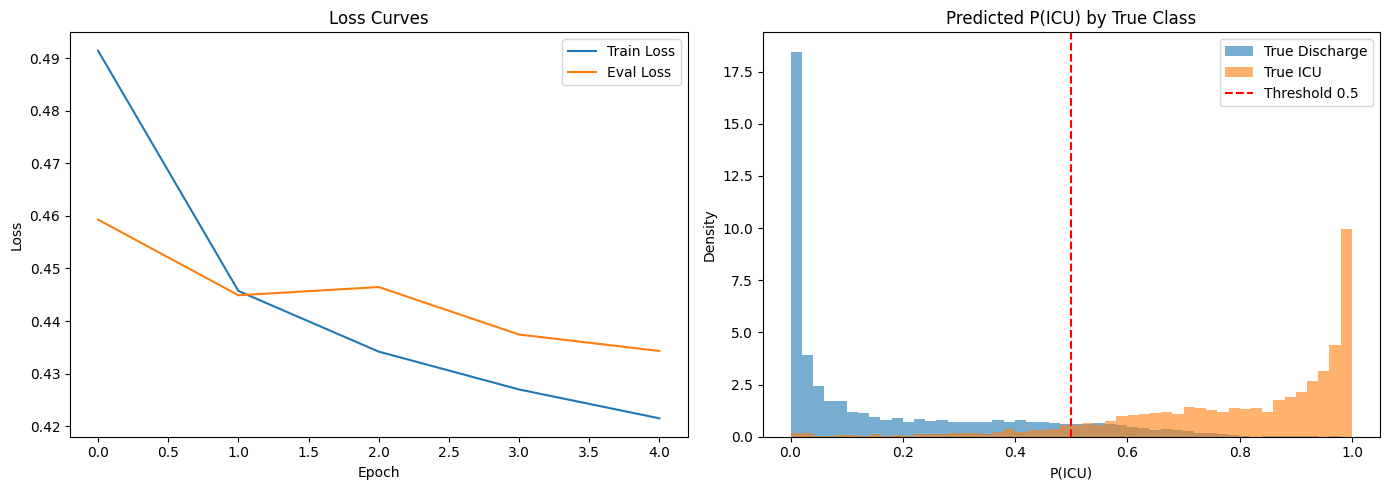

In [31]:
pred_probs = final_preds.numpy()  # (N, 2)
true_np    = true_labels.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(eval_losses, label="Eval Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].hist(pred_probs[true_np==0, 1], bins=50, alpha=0.6, label="True Discharge", density=True)
axes[1].hist(pred_probs[true_np==1, 1], bins=50, alpha=0.6, label="True ICU", density=True)
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Threshold 0.5")
axes[1].set_title("Predicted P(ICU) by True Class")
axes[1].set_xlabel("P(ICU)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


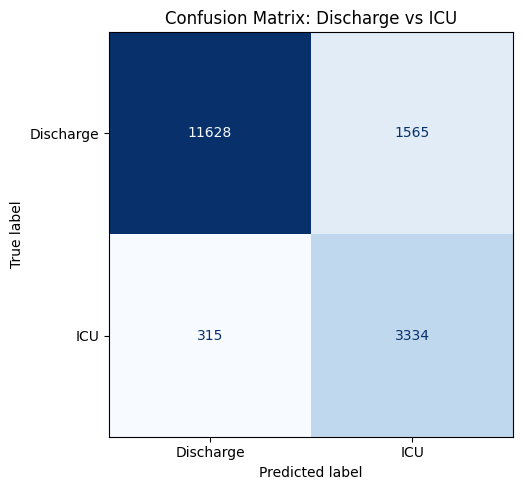

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predicted_classes = final_preds.argmax(dim=1).numpy()
true_np = true_labels.numpy()

cm = confusion_matrix(true_np, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Discharge", "ICU"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Discharge vs ICU")
plt.tight_layout()
plt.show()


Brier score (ICU class): 0.0778  (0=perfect, 0.25=no-skill)


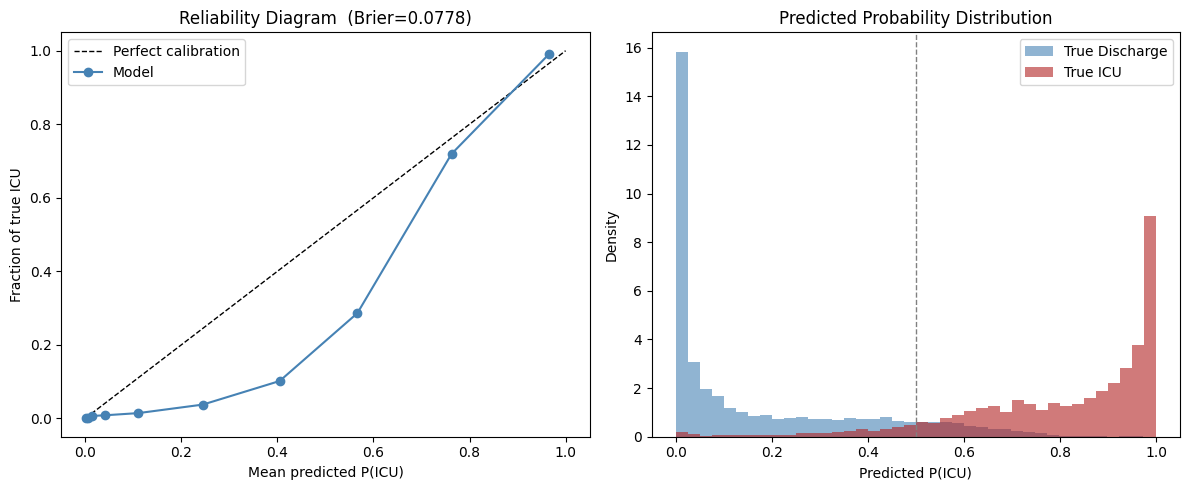

In [41]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

pred_np = final_preds.numpy()
true_np = true_labels.numpy()
p_icu   = pred_np[:, 1]

brier = brier_score_loss(true_np, p_icu)
print(f"Brier score (ICU class): {brier:.4f}  (0=perfect, 0.25=no-skill)")

# Reliability diagram
frac_pos, mean_pred = calibration_curve(true_np, p_icu, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: reliability diagram
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 'o-', color='steelblue', label='Model')
axes[0].set_xlabel('Mean predicted P(ICU)')
axes[0].set_ylabel('Fraction of true ICU')
axes[0].set_title(f'Reliability Diagram  (Brier={brier:.4f})')
axes[0].legend()

# Right: predicted probability histogram
axes[1].hist(p_icu[true_np == 0], bins=40, alpha=0.6, density=True, label='True Discharge', color='steelblue')
axes[1].hist(p_icu[true_np == 1], bins=40, alpha=0.6, density=True, label='True ICU',       color='firebrick')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted P(ICU)')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()


LOS bin breakpoints (steps):
               min  max  count
los_quantile                  
Q1 (shortest)    1    7   4424
Q2               8   11   4283
Q3              12   17   4076
18-29           18   29   3290
30-54           30   54    747
55+             55   88     22

          bin    n  icu_rate  f1_macro  f1_discharge  f1_icu  brier
Q1 (shortest) 4424    0.1490    0.9516        0.9849  0.9183 0.0241
           Q2 4283    0.2302    0.9174        0.9588  0.8761 0.0543
           Q3 4076    0.2684    0.8558        0.9131  0.7985 0.0919
        18-29 3290    0.2140    0.7343        0.8444  0.6241 0.1331
        30-54  747    0.2637    0.6259        0.6910  0.5608 0.2039
          55+   22    0.4091    0.4359        0.3333  0.5385 0.2767


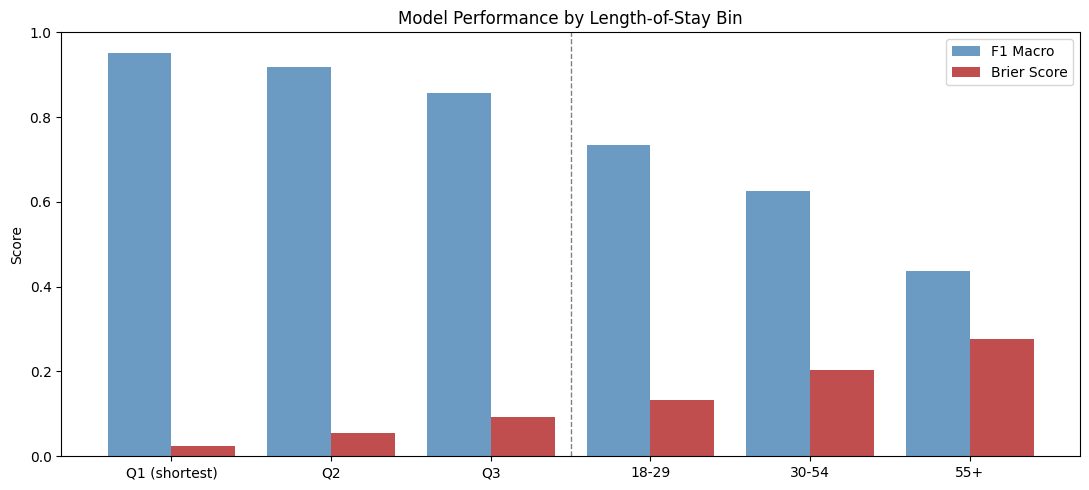

In [43]:
# Build a per-stay results dataframe
test_stay_ids = df_test.drop_duplicates('ed_stay_id')['ed_stay_id'].values

results_df = pd.DataFrame({
    'ed_stay_id':    test_stay_ids,
    'true_label':    true_labels.numpy(),
    'p_icu':         final_preds.numpy()[:, 1],
    'pred_label':    final_preds.argmax(dim=1).numpy(),
    'los_steps':     lengths_all.numpy(),
})

results_df['correct'] = (results_df['true_label'] == results_df['pred_label']).astype(int)

# First 3 quantiles via qcut on steps <= 17, then fixed bins for the long tail
short_mask = results_df['los_steps'] <= 17
long_mask  = results_df['los_steps'] >= 18

results_df.loc[short_mask, 'los_quantile'] = pd.qcut(
    results_df.loc[short_mask, 'los_steps'], q=3,
    labels=['Q1 (shortest)', 'Q2', 'Q3']
).astype(str)

results_df.loc[long_mask & (results_df['los_steps'] < 30),  'los_quantile'] = '18-29'
results_df.loc[long_mask & (results_df['los_steps'].between(30, 54)), 'los_quantile'] = '30-54'
results_df.loc[results_df['los_steps'] >= 55, 'los_quantile'] = '55+'

bin_order = ['Q1 (shortest)', 'Q2', 'Q3', '18-29', '30-54', '55+']
results_df['los_quantile'] = pd.Categorical(results_df['los_quantile'], categories=bin_order, ordered=True)

print('LOS bin breakpoints (steps):')
print(results_df.groupby('los_quantile', observed=True)['los_steps'].agg(['min','max','count']))
print()

# Per-bin metrics
from sklearn.metrics import f1_score, brier_score_loss

rows = []
for q, grp in results_df.groupby('los_quantile', observed=True):
    f1_mac  = f1_score(grp['true_label'], grp['pred_label'], average='macro')
    f1_dis  = f1_score(grp['true_label'], grp['pred_label'], pos_label=0, average='binary')
    f1_icu  = f1_score(grp['true_label'], grp['pred_label'], pos_label=1, average='binary')
    brier   = brier_score_loss(grp['true_label'], grp['p_icu'])
    icu_pct = grp['true_label'].mean()
    rows.append({'bin': q, 'n': len(grp), 'icu_rate': icu_pct,
                 'f1_macro': f1_mac, 'f1_discharge': f1_dis,
                 'f1_icu': f1_icu, 'brier': brier})

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(metrics_df))
ax.bar(x, metrics_df['f1_macro'], width=0.4, label='F1 Macro', color='steelblue', alpha=0.8)
ax.bar([i + 0.4 for i in x], metrics_df['brier'], width=0.4, label='Brier Score', color='firebrick', alpha=0.8)
ax.axvline(2.7, color='gray', linestyle='--', linewidth=1)  # separator between Q3 and fixed bins
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(metrics_df['bin'])
ax.set_ylabel('Score')
ax.set_title('Model Performance by Length-of-Stay Bin')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


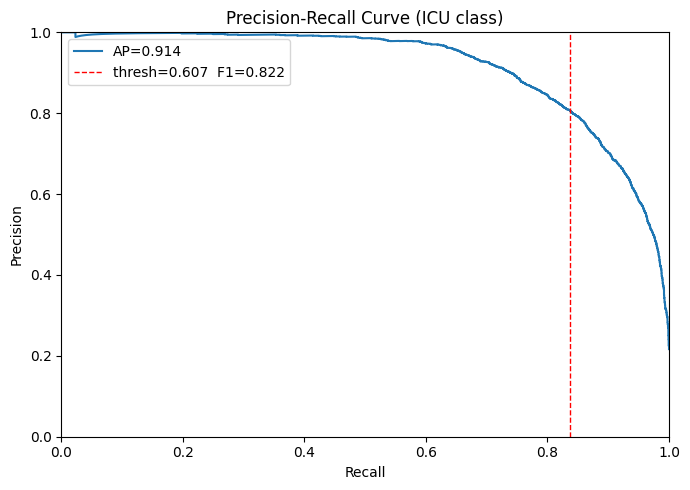

Optimal threshold: 0.6068
F1 at optimal:     0.8222
Average Precision: 0.9138


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pred_np = final_preds.numpy()
true_np = true_labels.numpy()

prec, rec, thresh = precision_recall_curve(true_np, pred_np[:, 1])
ap = average_precision_score(true_np, pred_np[:, 1])
f1s = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = f1s.argmax()
optimal_threshold = float(thresh[best_idx])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=1.5, label=f"AP={ap:.3f}")
ax.axvline(rec[best_idx], color="red", linestyle="--", linewidth=1,
           label=f"thresh={optimal_threshold:.3f}  F1={f1s[best_idx]:.3f}")
ax.set_title("Precision-Recall Curve (ICU class)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"F1 at optimal:     {f1s[best_idx]:.4f}")
print(f"Average Precision: {ap:.4f}")
